# DBSCAN and HDBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups together points that are closely packed together, marking as outliers points that lie alone in low-density regions. It requires two parameters: `eps` ($\epsilon$ the maximum distance between two points to be considered neighbors) and `min_samples` (the minimum number of points required to form a dense region). 

DBSCAN is particularly effective for datasets with noise and clusters of varying shapes and sizes.

https://fr.wikipedia.org/wiki/DBSCAN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.cluster import DBSCAN, HDBSCAN


In [2]:
# Generate sample data
X_moons, _ = make_moons(n_samples=300, noise=0.1, random_state=42)
X_blobs, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.5, random_state=42)

### 1. Plot the data

C:\Users\u011513\AppData\Local\Temp\ipykernel_15576\2864292740.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_moons[:, 0], X_moons[:, 1], cmap='viridis', s=50)


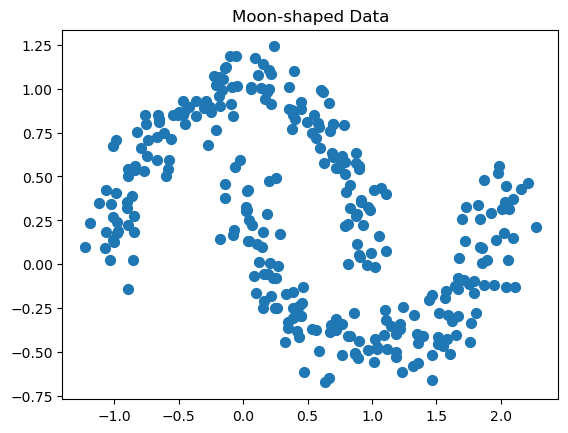

C:\Users\u011513\AppData\Local\Temp\ipykernel_15576\2864292740.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_blobs[:, 0], X_blobs[:, 1], cmap='viridis', s=50)


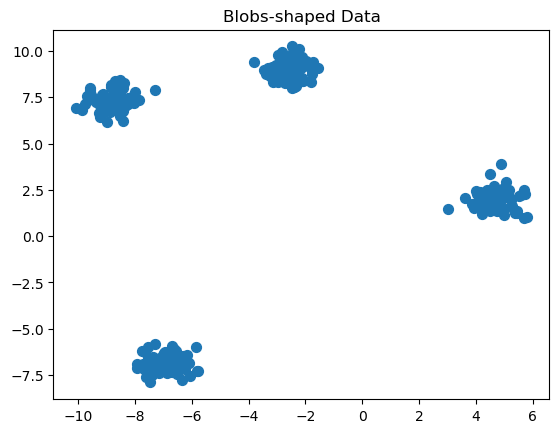

In [3]:
plt.scatter(X_moons[:, 0], X_moons[:, 1], cmap='viridis', s=50)
plt.title("Moon-shaped Data")
plt.show()

plt.scatter(X_blobs[:, 0], X_blobs[:, 1], cmap='viridis', s=50)
plt.title("Blobs-shaped Data")
plt.show()

### 2. Perform the DBSCAN clustering algorithm on the moon-shaped data and the blob-shaped data, and plot the results.


DBSCAN on Moon-shaped Data


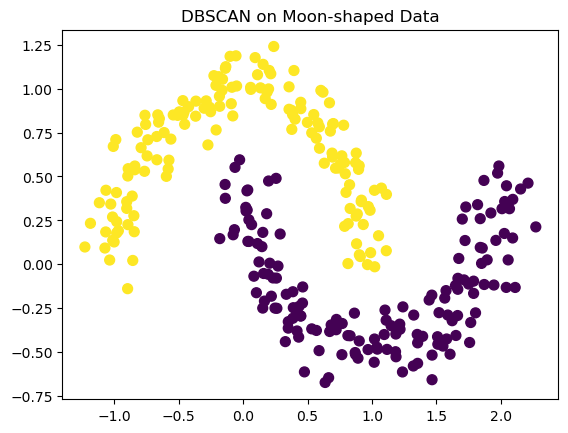

DBSCAN on Blob-shaped Data


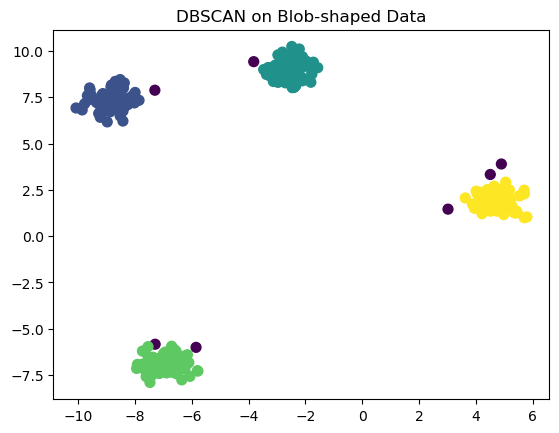

In [4]:
# To avoid repeating plotting code, we define a function that plots the clusters
def plot_clusters(X, labels, title):
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
    plt.title(title)
    plt.show()


print("DBSCAN on Moon-shaped Data")
dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
labels_moons = dbscan_moons.fit_predict(X_moons)
plot_clusters(X_moons, labels_moons, "DBSCAN on Moon-shaped Data")

# Exercise 2: DBSCAN on Blob-shaped Data
print("DBSCAN on Blob-shaped Data")
dbscan_blobs = DBSCAN(eps=0.5, min_samples=5)
labels_blobs = dbscan_blobs.fit_predict(X_blobs)
plot_clusters(X_blobs, labels_blobs, "DBSCAN on Blob-shaped Data")

### HDBSCAN

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) is an extension of the DBSCAN algorithm. It performs DBSCAN over varying $\epsilon$ values and integrates the result to find a clustering that gives the best stability over epsilon. This allows HDBSCAN to find clusters of varying densities, which DBSCAN struggles with.

Key features of HDBSCAN:
- **Hierarchical Clustering**: HDBSCAN builds a hierarchy of clusters, which can be visualized as a dendrogram.
- **Variable Density Clustering**: It can find clusters of varying densities, making it more flexible than DBSCAN.
- **Robust to Noise**: Like DBSCAN, HDBSCAN can identify and handle noise in the data.
- **Parameter Tuning**: The primary parameter for HDBSCAN is `min_cluster_size`, which determines the smallest size grouping that should be considered a cluster.

HDBSCAN is particularly useful for datasets with clusters of varying shapes, sizes, and densities.

For more information, you can visit the [official documentation](https://hdbscan.readthedocs.io/en/latest/).
```

### 3. Perform HDBSCAN algorithm for the Moon-shaped Data and the Blob-shaped Data and plot the results.

HDBSCAN on Moon-shaped Data


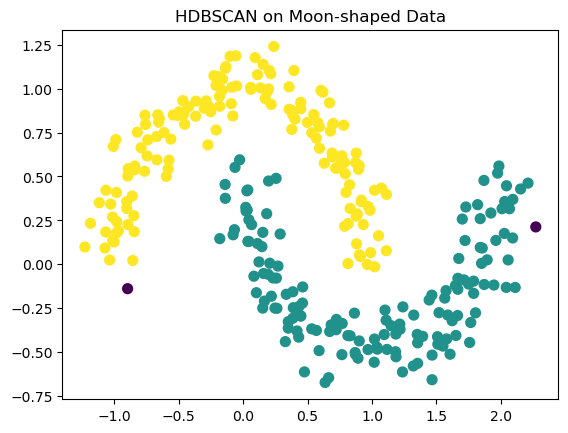

HDBSCAN on Blob-shaped Data


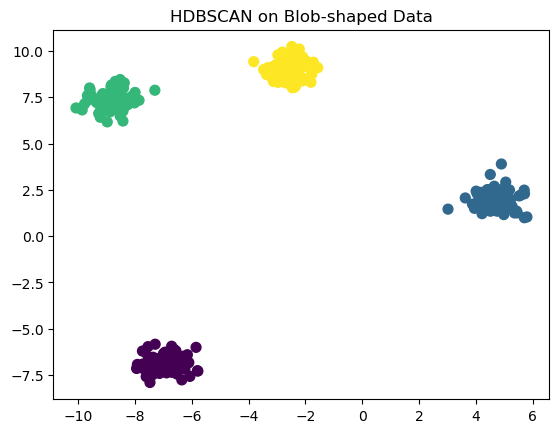

In [5]:

print("HDBSCAN on Moon-shaped Data")
hdbscan_moons = HDBSCAN(min_cluster_size=5)
labels_hdbscan_moons = hdbscan_moons.fit_predict(X_moons)
plot_clusters(X_moons, labels_hdbscan_moons, "HDBSCAN on Moon-shaped Data")

print("HDBSCAN on Blob-shaped Data")
hdbscan_blobs = HDBSCAN(min_cluster_size=5)
labels_hdbscan_blobs = hdbscan_blobs.fit_predict(X_blobs)
plot_clusters(X_blobs, labels_hdbscan_blobs, "HDBSCAN on Blob-shaped Data")

### 4. Find a good epsilon value for these two data types for the DBSCAN algorithm.

* You can iterate over several values of ```eps``` and ```min_samples``` and plot the result for each possibility.

Parameter Tuning for DBSCAN


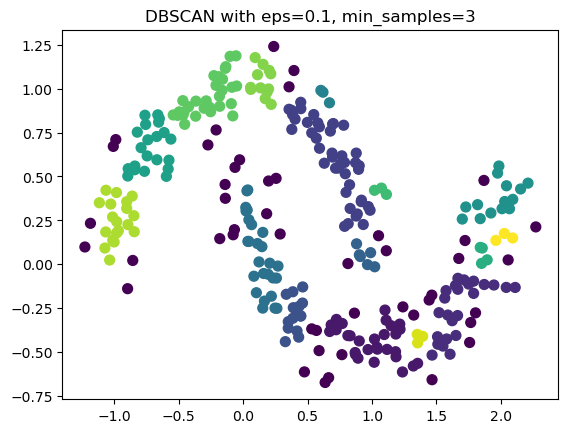

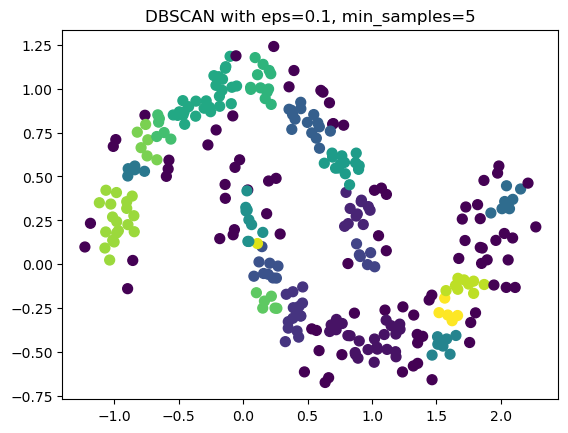

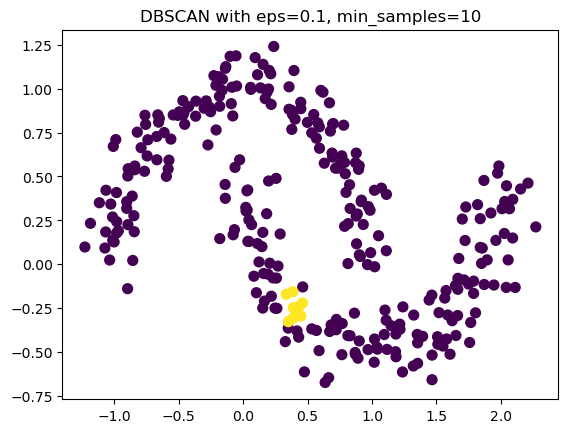

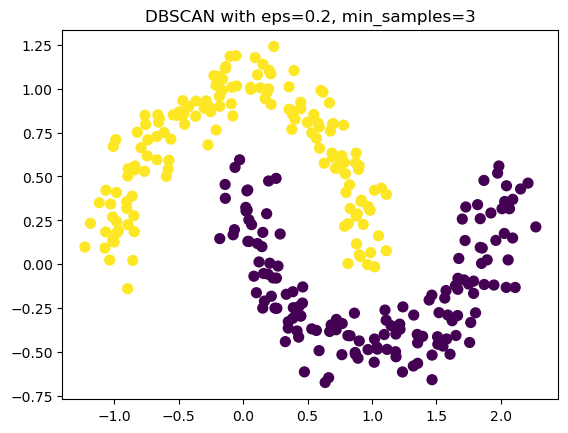

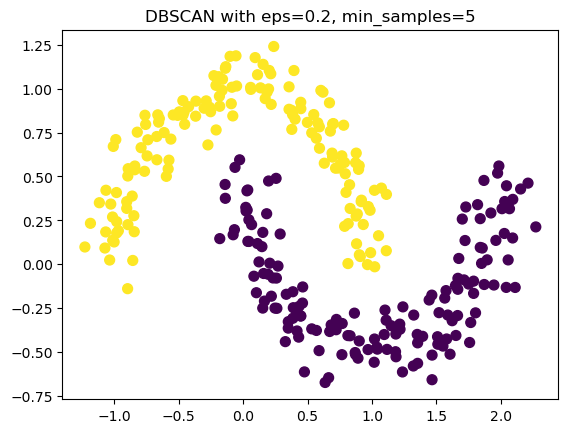

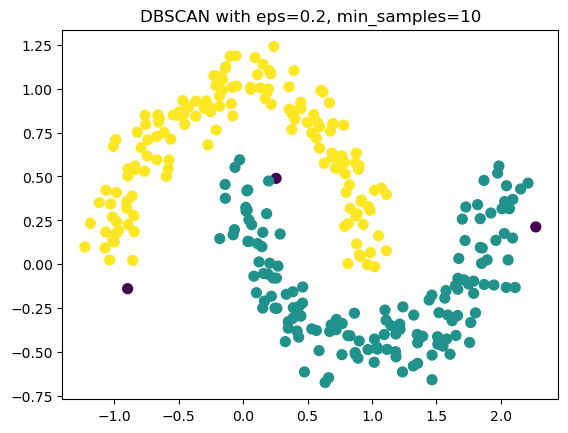

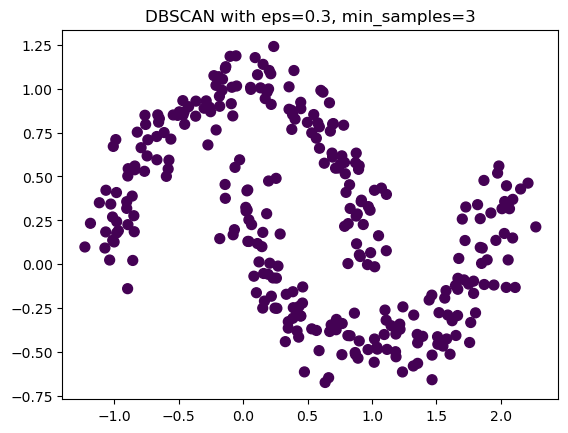

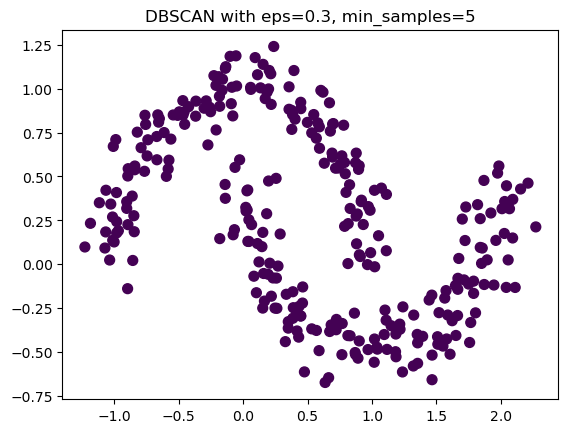

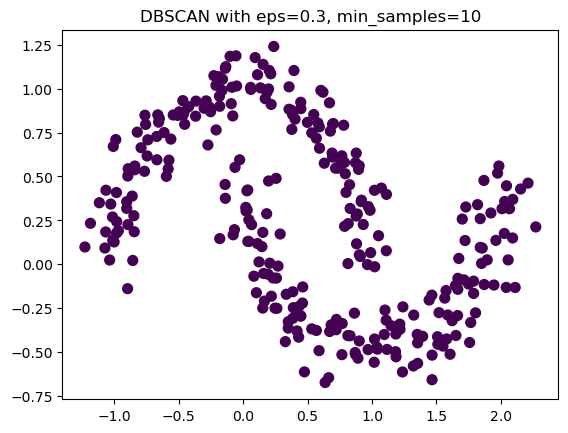

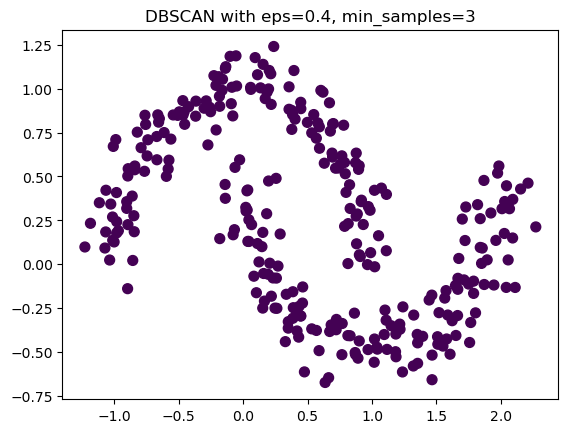

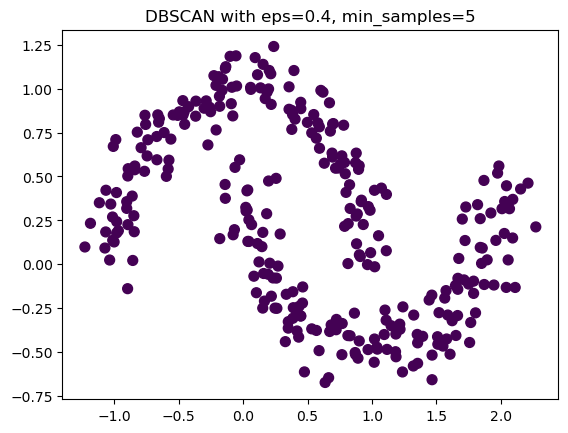

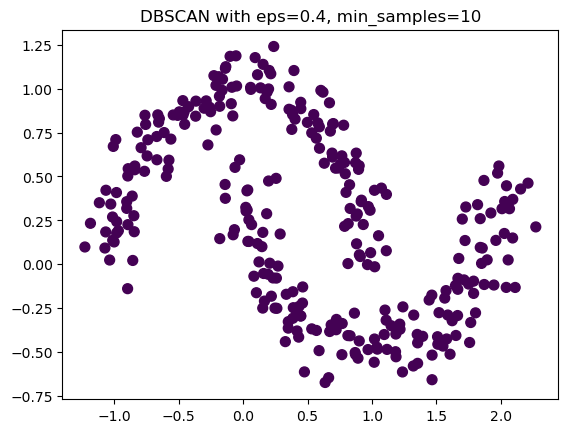

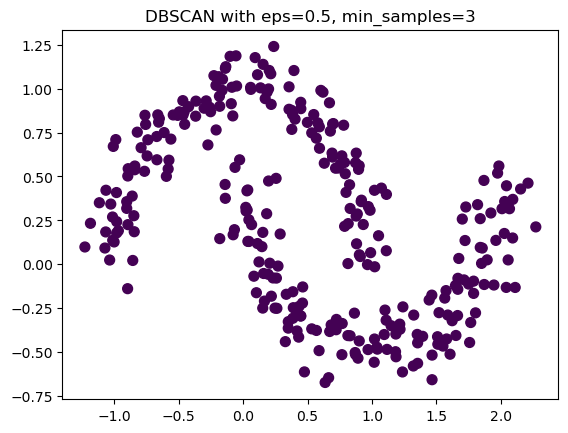

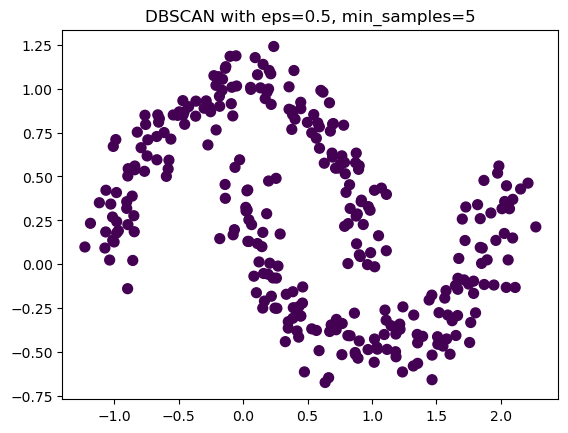

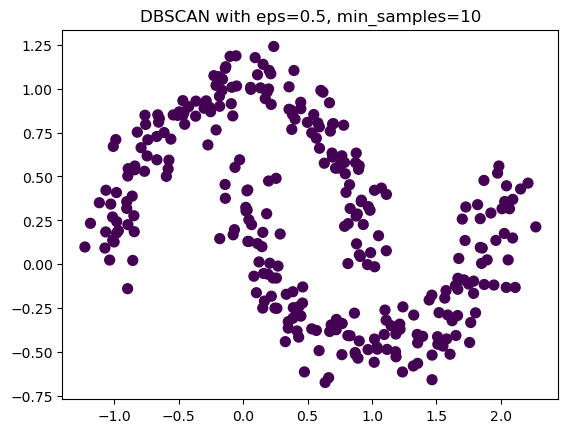

In [6]:
print("Parameter Tuning for DBSCAN")
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5]
min_samples_values = [3, 5, 10]
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_moons)
        plot_clusters(X_moons, labels, f"DBSCAN with eps={eps}, min_samples={min_samples}")



### 5. Similarly, perform a parameter tuning for HDBSCAN.

* See how easier it is !

Parameter Tuning for HDBSCAN


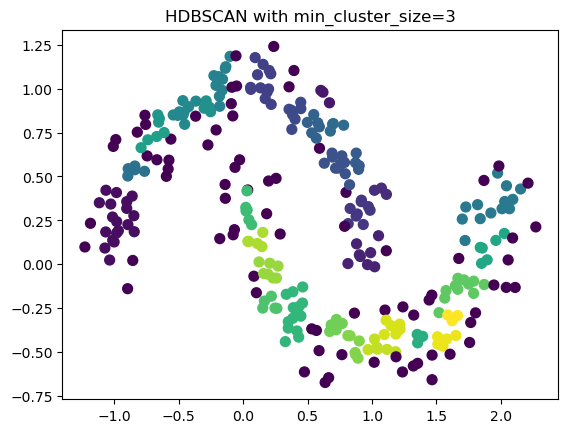

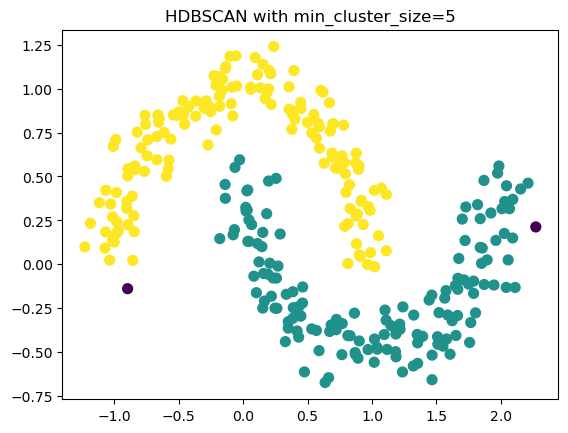

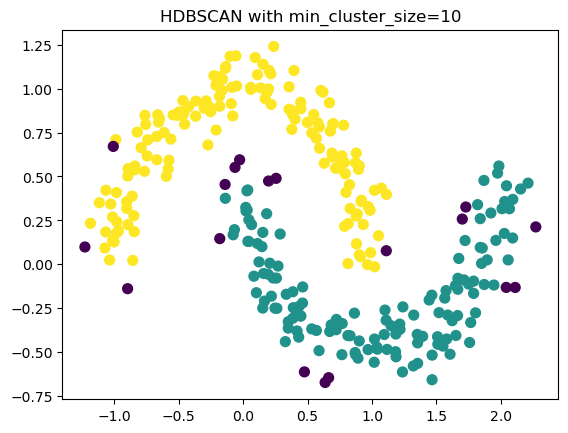

In [24]:
print("Parameter Tuning for HDBSCAN")
min_cluster_size_values = [3, 5, 10]
for min_cluster_size in min_cluster_size_values:
    hdbscan_cluster = HDBSCAN(min_cluster_size=min_cluster_size)
    labels = hdbscan_cluster.fit_predict(X_moons)
    plot_clusters(X_moons, labels, f"HDBSCAN with min_cluster_size={min_cluster_size}")

#### 6. Now perform HDBSCAN on the same datasets, using the ```hdbscan``` library

HDBSCAN on Moon-shaped Data


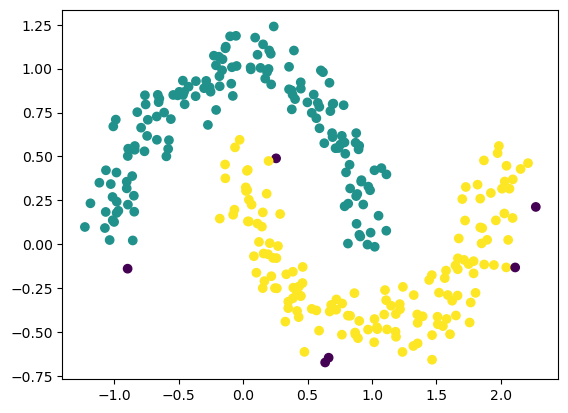

HDBSCAN on Blob-shaped Data


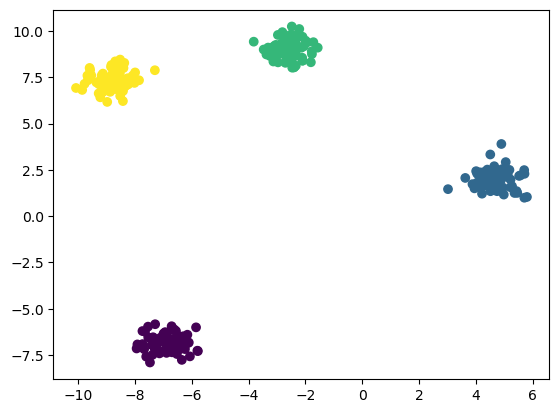

In [12]:
# !pip install hdbscan
import hdbscan

print("HDBSCAN on Moon-shaped Data")
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, gen_min_span_tree=True)
clusterer.fit(X_moons)
plt.scatter(X_moons[:,0], X_moons[:,1], c=clusterer.labels_)
plt.show()

print("HDBSCAN on Blob-shaped Data")
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, gen_min_span_tree=True)
clusterer.fit(X_blobs)
plt.scatter(X_blobs[:,0], X_blobs[:,1], c=clusterer.labels_)
plt.show()

### 7. Now load the ```clusterable_data.npy``` and compare K-means and HDBSCAN on it.

C:\Users\u011513\AppData\Local\Temp\ipykernel_15576\1595735729.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data[:, 0], data[:, 1], cmap='viridis', s=50, alpha=0.2)


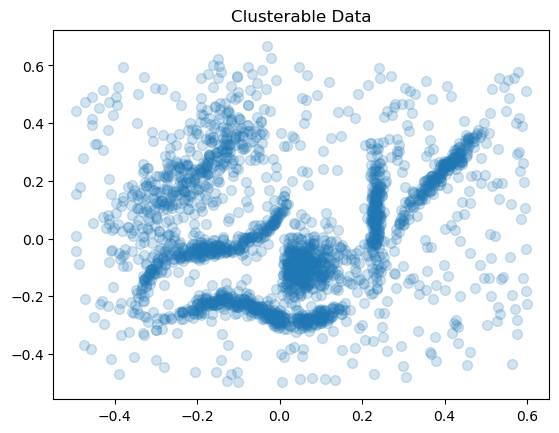

In [46]:
data = np.load('clusterable_data.npy')
plt.scatter(data[:, 0], data[:, 1], cmap='viridis', s=50, alpha=0.2)
plt.title("Clusterable Data")
plt.show()


c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


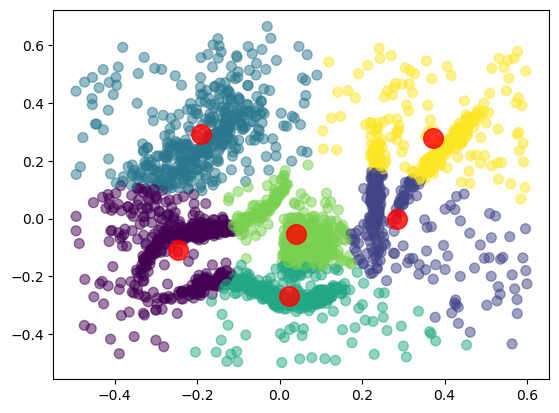

In [47]:
# Perform K-means clustering with 6 clusters 
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, init='k-means++')
kmeans.fit(data)

plt.scatter(data[:, 0], data[:, 1], c=kmeans.labels_, cmap='viridis', s=50, alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, alpha=0.8)
plt.show()


HDBSCAN on Clusterable Data


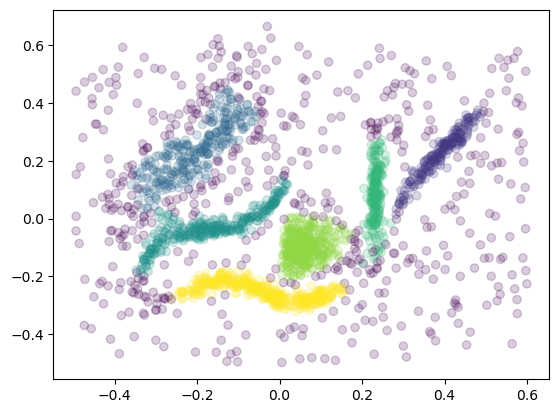

In [49]:

print("HDBSCAN on Clusterable Data")
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, gen_min_span_tree=True)
clusterer.fit(data)
plt.scatter(data[:,0], data[:,1], c=clusterer.labels_, alpha=0.2)
plt.show()

To go further, checkout https://pberba.github.io/stats/2020/01/17/hdbscan/.